In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools

300


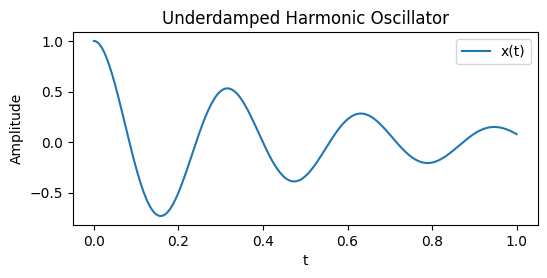

In [5]:

# ---------------------------
# Exact Solution function by Hand 
# ---------------------------

def mass_damper(delta,omega0,t): 
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    coss = np.cos(phi+omega*t)
    exp = np.exp(-delta*t)
    y = exp*2*A*coss
    return y

# ---------------------------
# sample ground truth
# ---------------------------
dd = 2
w00=20
times = np.linspace(0,1,300)
yexact = mass_damper(dd,w00,times)
print(len(yexact))

# ---------------------------
# plot 
# ---------------------------

pp.figure(figsize=(6,2.5))
pp.plot(times, yexact,label="x(t)")
pp.xlabel("t")
pp.ylabel("Amplitude")
pp.title("Underdamped Harmonic Oscillator")
pp.legend()
pp.show()


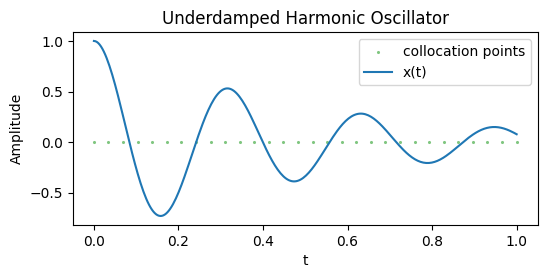

In [6]:
# ---------------------------
# Exact Solution function with solver function (Rutta-Kutta)
# ---------------------------
def underdamped(t, y, delta, omega0):
    x, v = y
    dxdt = v
    dvdt = -2*delta*v - omega0**2*x
    return [dxdt, dvdt]

# ---------------------------
# sample ground truth and set parameters values for underdamped solution
# ---------------------------
delta_val = 2
omega0_val = 20


underdamped_fixed = functools.partial(underdamped, delta=delta_val, omega0=omega0_val)

# Solve the ODE
y0 = [1.0, 0.0]                     # initial displacement=1, velocity=0
t_span = (0, 1)                     # simulate from 0 to 1 s
t_eval = np.linspace(*t_span, 300)  # time points for output
t_eval_col = np.linspace(*t_span, 30)  # reshape for compatibility with solve_ivp

sol = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_eval)
#print(len(sol.y[0]))
times = sol.t
yexact2 = sol.y[0]
#print(type(yexact2))
ydotexact2 = sol.y[1]

y_pred_phys = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_eval_col)
y_pred_phys2 = y_pred_phys.y[0]
ydot_pred_phys2 = y_pred_phys.y[1]
#print(len(y_pred_phys2))
# ---------------------------
# plot 
# ---------------------------
pp.figure(figsize=(6,2.5))

pp.scatter (t_eval_col, np.zeros_like(t_eval_col), s=5, lw=0, color="tab:green", label="collocation points", alpha=0.6)
pp.plot(times, yexact2,label="x(t)")
pp.xlabel("t")
pp.ylabel("Amplitude")
pp.title("Underdamped Harmonic Oscillator")
pp.legend()
pp.show()


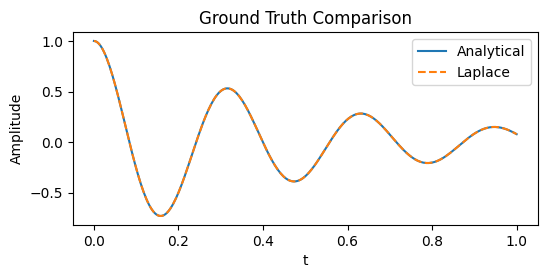

In [7]:
#Laplace transform method

def mass_damper_laplace(delta, omega0, t):
    omega = np.sqrt(omega0**2 - delta**2)
    term1 = np.exp(-delta * t) * np.cos(omega * t)
    term2 = (delta / omega) * np.exp(-delta * t) * np.sin(omega * t)
    return term1 + term2

yexact_laplace = mass_damper_laplace(delta_val, omega0_val, times)

pp.figure(figsize=(6,2.5))
pp.plot(times, yexact, label="Analytical", color="tab:blue")
pp.plot(times, yexact_laplace, label="Laplace", color="tab:orange", linestyle="--")
pp.xlabel("t")
pp.ylabel("Amplitude")
pp.title("Ground Truth Comparison")
pp.legend()
pp.show()
